In [2]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [3]:
seed = 2724

### Import data

In [5]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [14]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Use SHAP to explain the model on test data

In [16]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

100%|===================| 1494/1500 [01:19<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

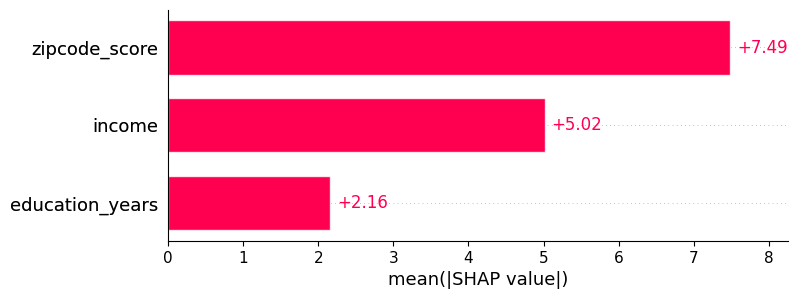

In [17]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [18]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [20]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.085462,-0.172202,5.865217
1,1.019984,-0.193786,-6.860764


### Let's put `group` and `zipcode_score` in the same plot

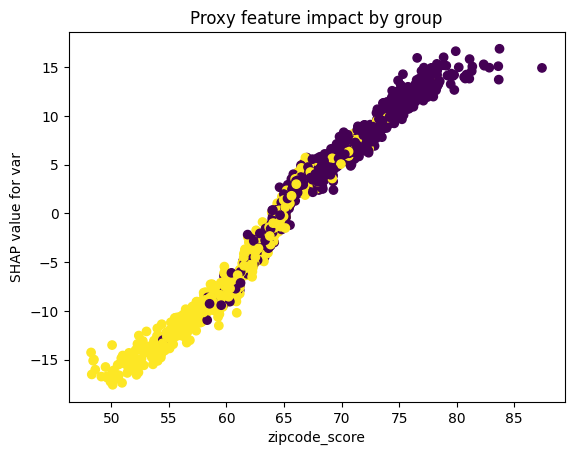

In [21]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

A SHAP value is a measure of a feature's contribution to the model's prediction. The value itself is calculated as the average marginal effect of that feature across all the different groupings of features.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

No, we did not use group in the model. We evaluated SHAP scores for certain features, split between the inclusion of variable "group" in the test set.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

Yes, it appears to be correlated with group. In particular, the SHAP values for zipcode_score are very different across groups, which suggests the model is using zipcode_score in a group-dependent way (as a possible proxy).

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

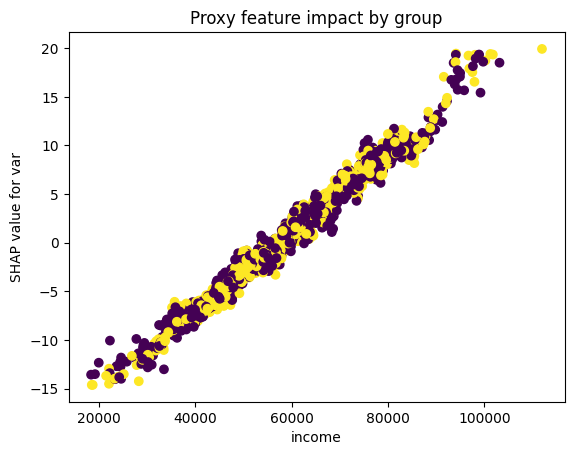

In [22]:
plot_shap("income")

There is far more overlap in SHAP values between the two groups. This is different from zipcode_score, where the groups are much more separated and the SHAP values differ a lot more.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

What happens if you retrain the model without zipcode_score?


Are the SHAP patterns stable across different train/test splits or random seeds?